In [1]:
import osmnx as ox
import networkx as nx

In [2]:
places = [
    "Champaign, Illinois, USA",
    "Urbana, Illinois, USA"
]
gdf = ox.geocode_to_gdf(places)

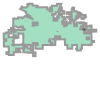

In [3]:
gdf.unary_union

In [4]:
#G1 = ox.graph_from_polygon(gdf['geometry'][1], network_type="walk")
#G0 = ox.graph_from_polygon(gdf['geometry'][0], network_type="walk")

In [5]:
##ox.plot_graph(ox.graph_from_polygon(gdf.unary_union))

KeyboardInterrupt: 

In [6]:
import osmnx as ox

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')



In [9]:
import json

'''nodes = champaign.nodes

for i,node in enumerate(nodes):
    if not i:
        print(node)
        views = [view for view in champaign[node].values()]
        for view in views:
            print(view[0]['name'])'''



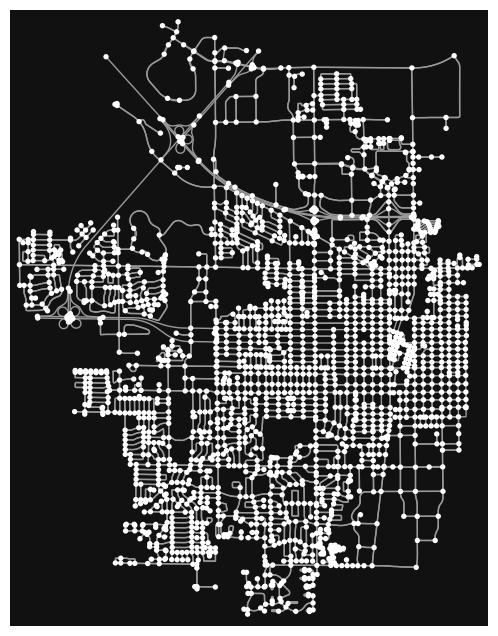

In [7]:
import os
import sys
import osmnx as ox
import networkx as nx
import numpy as np

champaign = ox.graph_from_place('Champaign, IL, USA', network_type='drive')
champaign = ox.speed.add_edge_speeds(champaign)
champaign = ox.speed.add_edge_travel_times(champaign)

travel_times_dict = nx.get_edge_attributes(champaign, 'travel_time')

indexes = {node: i for i, node in enumerate(champaign.nodes)}

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)



ox.plot_graph(champaign)

from utils import node_from_address

starting_node = node_from_address(champaign, '1008 S 4th Street, Champaign, IL')
final_node = node_from_address(champaign, '2610 N Prospect Ave, Champaign, IL')

In [ ]:
import networkx as nx
import numpy as np

for i, node in enumerate(champaign.nodes):
    if node == starting_node:
        start_idx = i
    elif node == final_node:
        final_idx = i
        
print(start_idx, final_idx)
print(starting_node)

1492 1964
38089239


In [17]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

#G = champaign.to_directed()

all_nodes = list(G.nodes())

indexes = {val: i for i, val in enumerate(all_nodes)}

out_edges = champaign.out_edges()
in_edges = champaign.in_edges()

'''A = np.zeros((len(champaign.nodes()), len(champaign.edges())))

for i, node in enumerate(champaign.nodes()):
    for j, edge in enumerate(out_edges):
        if edge[0] == node:
             A[i][j] = -1
             
    for j, edge in enumerate(in_edges):
        if edge[1] == node:
             A[i][j] = 1'''



#ec = ['b' if (u, v) in flowed_edges else 'r' for u, v, k in G.edges(keys=True)]

#fig, ax = ox.plot_graph_route(champaign, route,  node_color='w', node_edgecolor='k', node_size=0, 
                           #node_zorder=3, edge_linewidth=2)



'A = np.zeros((len(champaign.nodes()), len(champaign.edges())))\n\nfor i, node in enumerate(champaign.nodes()):\n    for j, edge in enumerate(out_edges):\n        if edge[0] == node:\n             A[i][j] = -1\n             \n    for j, edge in enumerate(in_edges):\n        if edge[1] == node:\n             A[i][j] = 1'

  (0, 0)	-1.0
  (982, 0)	1.0
  (0, 1)	-1.0
  (1, 1)	1.0
  (0, 2)	-1.0
  (993, 2)	1.0
  (1, 3)	-1.0
  (2, 3)	1.0
  (1, 4)	-1.0
  (1793, 4)	1.0
  (1, 5)	-1.0
  (983, 5)	1.0
  (0, 6)	1.0
  (1, 6)	-1.0
  (1, 7)	1.0
  (2, 7)	-1.0
  (2, 8)	-1.0
  (3, 8)	1.0
  (2, 9)	-1.0
  (1664, 9)	1.0
  (3, 10)	-1.0
  (4, 10)	1.0
  (2, 11)	1.0
  (3, 11)	-1.0
  (3, 12)	-1.0
  :	:
  (2131, 6008)	-1.0
  (1820, 6009)	1.0
  (2132, 6009)	-1.0
  (2132, 6010)	-1.0
  (2133, 6010)	1.0
  (42, 6011)	1.0
  (2133, 6011)	-1.0
  (1541, 6012)	1.0
  (2134, 6012)	-1.0
  (224, 6013)	1.0
  (2135, 6013)	-1.0
  (329, 6014)	1.0
  (2136, 6014)	-1.0
  (1420, 6015)	1.0
  (2137, 6015)	-1.0
  (1725, 6016)	1.0
  (2138, 6016)	-1.0
  (2138, 6017)	-1.0
  (2139, 6017)	1.0
  (1733, 6018)	1.0
  (2139, 6018)	-1.0
  (2138, 6019)	1.0
  (2139, 6019)	-1.0
  (392, 6020)	1.0
  (2140, 6020)	-1.0


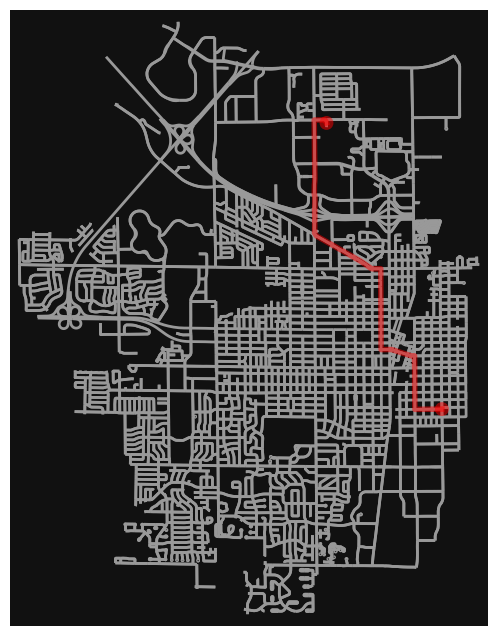

In [18]:
print(A)

Set parameter Username
Academic license - for non-commercial use only - expires 2024-10-13
442.70000000000005
2141
[[-1. -1. -1. ...  0.  0.  0.]
 [ 0.  1.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  1.  1.  0.]
 [ 0.  0.  0. ... -1. -1.  0.]
 [ 0.  0.  0. ...  0.  0. -1.]]
[37963930, 37970446, 37970900, 37973363, 37981216, 37982940, 37982955, 37985580, 37986833, 37988893, 37989318, 37997462, 37999274, 38003206, 38003956, 38007920, 38009727, 38009731, 38009732, 38009741, 38035942, 38047403, 38050678, 38054101, 38058593, 38058595, 38058597, 38058598, 38058599, 38068242, 38069438, 38083033, 38089235, 38089239, 38090214, 38128444, 38133216, 38135457, 38135864, 38146585, 194668461, 1518917867, 1929711495, 1929711603, 3273524767, 5440546961, 5440546962, 5680617585, 5680618729, 6119772432, 6119772436, 10101638415, 10101649866, 10101649870]


AttributeError: 'NoneType' object has no attribute 'values'

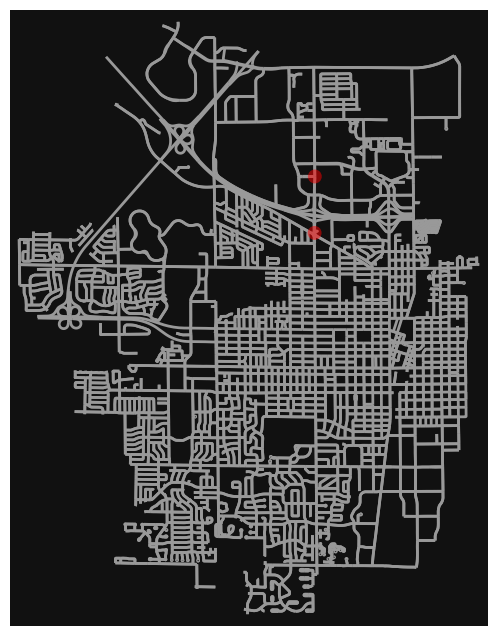

In [10]:
import networkx as nx
import gurobipy as gp
from gurobipy import GRB
import numpy as np

G = nx.DiGraph()

edges = champaign.edges

G.add_nodes_from(champaign.nodes())
G.add_edges_from(champaign.edges())

banned_coords = [(40.130902, -88.243662), (40.130462, -88.238855), (40.132660, -88.243546)]

banned_nodes = [ox.nearest_nodes(champaign, lon, lat) for lat, lon in banned_coords]

banned_nodes = []

#edge_idx = [i for i, edge in enumerate(edges) if edge == (37982929, 37982924, 0)]

#print(edge_idx)

n_points = len(champaign.nodes)
n_edges = len(champaign.edges)

A = np.zeros((n_points, n_edges))



for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        print(u, v)
        continue

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

#print(sum(A[edge_idx[0]]))

#A[edge_idx[0]] = np.zeros(n_edges)

#print(sum(A[edge_idx[0]]))


b = np.zeros(n_points)

b[indexes[starting_node]] = -1
b[indexes[final_node]] = 1

f = np.zeros(n_edges)

m = gp.Model("lp")

m.Params.LogToConsole = 0
m.Params.Method = 0

f = m.addMVar(shape=n_edges, vtype=GRB.CONTINUOUS, lb=0, name="")

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

m.addConstr(A@f==b)
#m.addConstr(f[edge_idx] == 0)
obj = np.array(weights)@f
m.setObjective(obj, GRB.MINIMIZE)
m.optimize()

print(m.ObjVal)

flows = m.getAttr("X", m.getVars())

flowed_edges_idx = []
flowed_edges = []

for i in range(len(flows)):
        if flows[i]:
            flowed_edges_idx += [i]

route  = []

for i, edge in enumerate(champaign.edges):
    if i in flowed_edges_idx:
        route += [edge[0]]

print(G.number_of_nodes())
print(A)

print(route)

fig, ax = ox.plot_graph_route(champaign, route,  node_color='w', node_edgecolor='k', node_size=0, 
                                node_zorder=3, edge_linewidth=2)

In [25]:
A[4, 1]

0.0

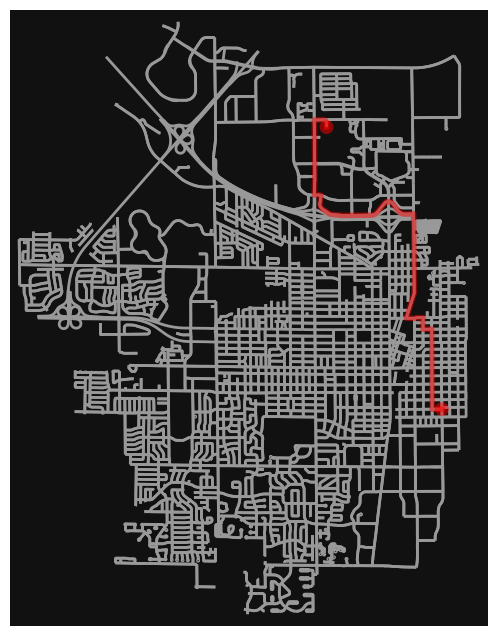

[38089239, 37982940, 37982936, 37982933, 37982929, 37982924, 37982921, 37982918, 37982915, 37982911, 37982901, 38057028, 38024753, 37979007, 37979011, 37979013, 38022941, 38048907, 38035359, 38092882, 38092887, 38027627, 38091002, 37945299, 38092893, 38092898, 38092900, 38092901, 38023744, 11328611089, 38075363, 38075393, 38129169, 38146585, 37963930, 38133216, 194668461, 1518917867, 5440546961, 5440546962, 2375296144]


In [20]:
route = nx.shortest_path(champaign, starting_node, final_node)

fig, ax = ox.plot_graph_route(champaign, route, node_color='w', node_edgecolor='k', node_size=0,
                             node_zorder=3, edge_linewidth=2)

print(route)

True
41


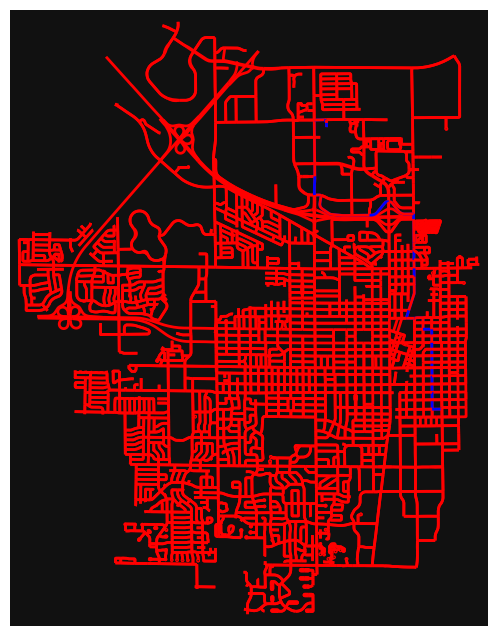

[0. 0. 0. ... 0. 0. 0.]


In [43]:



print(b)

In [47]:
'''for node in nodes:
    info = champaign[node]
    s_4th = 0
    e_arm = 0
    for connecting_node in info:
        if not 'name' in champaign[node][connecting_node][0]:
            continue #== 'South Fourth Street':
        if champaign[node][connecting_node][0]['name'] == 'South Fourth Street' :
            s_4th = 1
        if champaign[node][connecting_node][0]['name'] == 'East Armory Avenue':
            e_arm = 1
        if s_4th + e_arm >= 2:
            print(champaign[node])
            #print(champaign[node], champaign[connecting_node])
        #print(1)'''

"for node in nodes:\n    info = champaign[node]\n    s_4th = 0\n    e_arm = 0\n    for connecting_node in info:\n        if not 'name' in champaign[node][connecting_node][0]:\n            continue #== 'South Fourth Street':\n        if champaign[node][connecting_node][0]['name'] == 'South Fourth Street' :\n            s_4th = 1\n        if champaign[node][connecting_node][0]['name'] == 'East Armory Avenue':\n            e_arm = 1\n        if s_4th + e_arm >= 2:\n            print(champaign[node])\n            #print(champaign[node], champaign[connecting_node])\n        #print(1)"